In [1]:
# notebook magics
# inline/notebook/interactive
%matplotlib notebook
%load_ext autoreload
%autoreload 2

import os
# os.chdir("./3D")
os.getcwd()

'/home/nb0817/ps-model-exact/3D'

In [2]:
from argparse import Namespace
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
# make figures higher resolution (larger)
plt.rcParams['figure.dpi'] = 100
# A decent backend for animations
plt.rcParams["animation.html"] = "jshtml"
# let 'em get big
plt.rcParams["animation.embed_limit"] = 100  # MB

# import our code that we need
import os, sys 
sys.path.append(os.path.abspath("lib")) # N.B: NB needs this line to run locally!!

import fixed_center_of_mass_exact_3D as fcm

os.chdir("../2D")
import fixed_center_of_mass_exact_2D as fcm2D

[xp] backend set to numpy


In [92]:
base_params = {
        'g_1': 1.0, 'g_2': 1.0,
        'M_1': 2e3, 'M_2': 2e3,
        'NR': 53, 'Nr': 51, 'Ng': 52,
        'J': 0, 'potential': 'erf_coulomb',
        'preconditioner': 'naive',
        'verbosity': 0, 't': 64,
        'extent':np.array([0.1,3,4])
    }
args = Namespace(**base_params)
H = fcm.Hamiltonian(args)

Potential: erf_coulomb
extent in unscaled coords: [0.1 3. ] 4.0
extent in   scaled coords: [ 0.56237647 16.87129405] 0.7112673139754199
diff Vsph_ 4.032799082496616e-16
[Build Vsph from Vgrid] Elapsed time: 7.2e+05us
Preconditioner requires 1MB.
[Build preconditioner naive] Elapsed time: 31.6us


In [93]:
# Ad_vn, Ad_n = H.BO_spectrum()
# print(Ad_n.shape)
# print(Ad_vn.shape)
Ad_vn, U_n, U_v, Ad_n = H._build_preconditioner_BO()

Building U_n
[Build Hel] Elapsed time: 2.66e+06us
[Diag  Hel] Elapsed time: 6.12e+06us
[Phase match U_n] Elapsed time: 6.65e+05us
[Build Hbo] Elapsed time: 7.27e+03us
[Diag  Hbo] Elapsed time: 2.12e+06us
[Phase match U_v] Elapsed time: 1.65e+04us


<IPython.core.display.Javascript object>

[-1.19606649 -0.15851246  0.07977072  0.35191325  0.44023724]


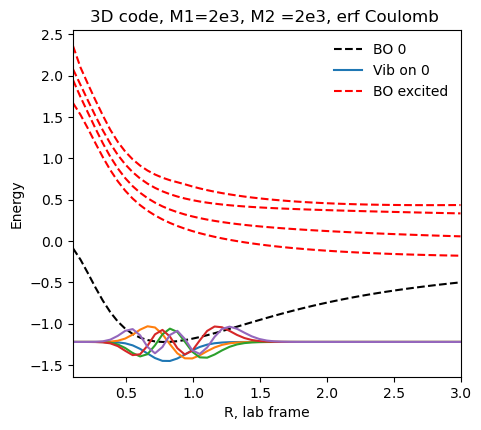

In [94]:
fig,ax = plt.subplots(figsize=(5,4.5))
n=0
print(Ad_vn[0,:5])
ax.plot(H.R_lab, (Ad_n[:,n]), color='k', label="BO 0", linestyle='--')
ax.plot(H.R_lab, U_v[n,:,0]*0.5 + np.min(Ad_n[:,n]), label="Vib on 0")
ax.plot(H.R_lab, U_v[n,:,1]*0.5 + np.min(Ad_n[:,n]))
ax.plot(H.R_lab, U_v[n,:,2]*0.5 + np.min(Ad_n[:,n]))
ax.plot(H.R_lab, U_v[n,:,3]*0.5 + np.min(Ad_n[:,n]))
ax.plot(H.R_lab, U_v[n,:,4]*0.5 + np.min(Ad_n[:,n]))
# ax.plot(H.R_lab, Ad_n[:,0])
ax.plot(H.R_lab, Ad_n[:,1], c='r', linestyle='--', label="BO excited") 
ax.plot(H.R_lab, Ad_n[:,2], c='r', linestyle='--')
ax.plot(H.R_lab, Ad_n[:,3], c='r', linestyle='--')
ax.plot(H.R_lab, Ad_n[:,4], c='r', linestyle='--')
ax.set_xlabel("R, lab frame")
ax.set_ylabel("Energy")
ax.set_title("3D code, M1=2e3, M2 =2e3, erf Coulomb ")
ax.legend(frameon=False)
ax.set_xmargin(0)
display(fig)
fig.savefig("erf_2e1.png")

In [20]:
H2D = fcm2D.Hamiltonian(args)
Ad_2vn, Ad_2n = H2D.BO_spectrum()

KeyError: 'erf_coulomb'

/tmp/ipykernel_2148510/1995293560.py:4: RuntimeWarning: invalid value encountered in divide
  test = -erf(a*rl)/rl


<IPython.core.display.Javascript object>

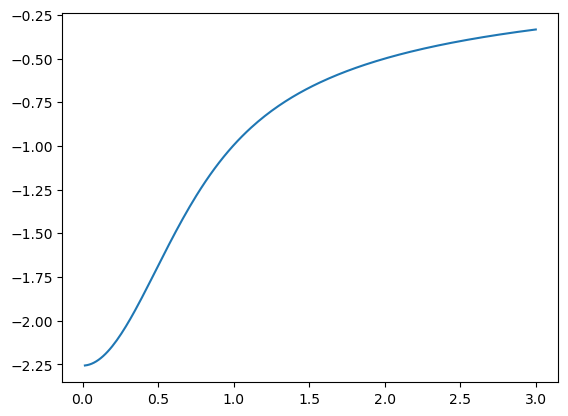

In [25]:
from scipy.special import erf
rl = np.linspace(0,3,200)
a = 2
test = -erf(a*rl)/rl

fig,ax = plt.subplots()
ax.plot(rl,test)
display(fig)

<IPython.core.display.Javascript object>

offset 0.009969151575397635


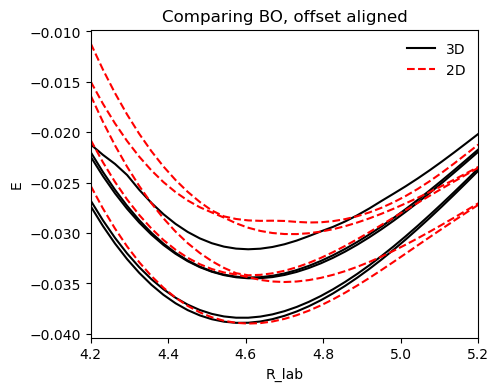

In [63]:
fig,ax = plt.subplots(figsize=(5,4))
argmin = np.argmin(Ad_n[:,0])
offset = Ad_n[argmin,0]-Ad_2n[argmin,0]
print("offset",offset)
ax.plot(H.R_lab, Ad_n[:,0], c='k', label="3D")
ax.plot(H.R_lab, Ad_n[:,1], c='k') 
ax.plot(H.R_lab, Ad_n[:,2], c='k')
ax.plot(H.R_lab, Ad_n[:,3], c='k')
ax.plot(H.R_lab, Ad_n[:,4], c='k')

ax.plot(H.R_lab, Ad_2n[:,0]+offset, linestyle="--", c='r', label="2D")
ax.plot(H.R_lab, Ad_2n[:,1]+offset, linestyle="--", c='r') 
ax.plot(H.R_lab, Ad_2n[:,2]+offset, linestyle="--", c='r')
ax.plot(H.R_lab, Ad_2n[:,3]+offset, linestyle="--", c='r')
ax.plot(H.R_lab, Ad_2n[:,4]+offset, linestyle="--", c='r')
ax.set_title("Comparing BO, offset aligned")
ax.set_xlabel("R_lab")
ax.set_ylabel("E")
ax.set_xmargin(0)
ax.legend(frameon=False)
display(fig)